# Expectation-Maximization (EM) Algorithm on Galton Family Heights

This notebook implements a **two‑component Gaussian mixture model** without labels.  
We use the famous GaltonFamilies dataset and try to separate the heights into two clusters: *children* and *fathers*, **without** using the family identifiers.  
The EM algorithm iteratively assigns soft membership probabilities (E‑step) and updates the parameters of the two Gaussians (M‑step).

## 0. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Setup and Data Loading

In [ ]:
import csv
import math
import os

# Get datasets
FILE_PART1 = "/content/drive/MyDrive/GaltonFamilies.csv"
FILE_PART2 = "/content/drive/MyDrive/IMDB_Dataset.csv"

In [ ]:
# === Load The Dataset ===
heights = []
seen_families = set()

with open(FILE_PART1, "r") as file:
    reader = csv.reader(file)
    next(reader)  # skip header

    for row in reader:
        family_id = row[1]
        father_height = float(row[2])
        child_height = float(row[8])

        # Add child's height to our dataset
        heights.append(child_height)

        # Add father only once per family to avoid duplicates
        if family_id not in seen_families:
            heights.append(father_height)
            seen_families.add(family_id)

N = len(heights)
print(f"Total individuals in the combined dataset: {N}")
print(f"First 5 heights: {heights[:5]}")

Total individuals in the combined dataset: 1139
First 5 heights: [73.2, 78.5, 69.2, 69.0, 69.0]


## 2. EM Algorithm Implementation

In [ ]:
# Gaussian probability density function
def calculate_gaussian_prob(x, mean, variance):
    coefficient = 1.0 / math.sqrt(2.0 * math.pi * variance)
    exponent = math.exp(-0.5 * ((x - mean) ** 2) / variance)
    return coefficient * exponent

In [ ]:
# === Initialization ===
# Guesses for the two clusters
mu1 = 64.0
mu2 = 72.0
var1 = 10.0
var2 = 10.0
pi1 = 0.5
pi2 = 0.5

# Responsibility vectors (soft assignments)
weights1 = [0.0] * N
weights2 = [0.0] * N

# Convergence settings
tolerance = 1e-8
max_iterations = 100
previous_log_likelihood = None

print("Iteration | mu1 (Children) | mu2 (Fathers) | var1 | var2 | pi1 | pi2 | Log-Likelihood")
print("-" * 85)

Iteration | mu1 (Children) | mu2 (Fathers) | var1 | var2 | pi1 | pi2 | Log-Likelihood
-------------------------------------------------------------------------------------


In [ ]:
# === The EM Loop ===
for iteration in range(max_iterations):
    log_likelihood = 0.0

    # --- E-STEP ---
    for i in range(N):
        x = heights[i]

        prob_is_group1 = pi1 * calculate_gaussian_prob(x, mu1, var1)
        prob_is_group2 = pi2 * calculate_gaussian_prob(x, mu2, var2)
        total_prob = prob_is_group1 + prob_is_group2

        log_likelihood += math.log(total_prob)

        weights1[i] = prob_is_group1 / total_prob
        weights2[i] = prob_is_group2 / total_prob

    # Print current state
    print(f"{iteration:9} | {mu1:14.2f} | {mu2:10.2f} | {var1:4.2f} | {var2:4.2f} | {pi1:3.2f} | {pi2:3.2f} | {log_likelihood:.2f}")

    # Convergence check
    if previous_log_likelihood is not None:
        change = abs(log_likelihood - previous_log_likelihood)
        if change < tolerance:
            print(f"\n Converged after {iteration} iterations.")
            break
    previous_log_likelihood = log_likelihood

    # --- M-STEP ---
    N1 = sum(weights1)
    N2 = sum(weights2)

    pi1 = N1 / N
    pi2 = N2 / N

    mu1 = sum(weights1[i] * heights[i] for i in range(N)) / N1
    mu2 = sum(weights2[i] * heights[i] for i in range(N)) / N2

    var1 = sum(weights1[i] * ((heights[i] - mu1) ** 2) for i in range(N)) / N1
    var2 = sum(weights2[i] * ((heights[i] - mu2) ** 2) for i in range(N)) / N2

print("\nFinal parameters:")
print(f"mu1 = {mu1:.2f}, var1 = {var1:.2f}, pi1 = {pi1:.3f}")
print(f"mu2 = {mu2:.2f}, var2 = {var2:.2f}, pi2 = {pi2:.3f}")

        0 |          64.00 |      72.00 | 10.00 | 10.00 | 0.50 | 0.50 | -3238.13
        1 |          64.99 |      70.08 | 7.11 | 5.41 | 0.56 | 0.44 | -3048.92
        2 |          64.97 |      70.07 | 7.15 | 5.23 | 0.56 | 0.44 | -3048.61
        3 |          64.94 |      70.07 | 7.09 | 5.16 | 0.56 | 0.44 | -3048.51
        4 |          64.93 |      70.07 | 7.03 | 5.13 | 0.56 | 0.44 | -3048.43
        5 |          64.91 |      70.08 | 6.97 | 5.10 | 0.56 | 0.44 | -3048.37
        6 |          64.90 |      70.07 | 6.91 | 5.09 | 0.55 | 0.45 | -3048.32
        7 |          64.88 |      70.07 | 6.87 | 5.08 | 0.55 | 0.45 | -3048.28
        8 |          64.87 |      70.07 | 6.83 | 5.08 | 0.55 | 0.45 | -3048.24
        9 |          64.86 |      70.06 | 6.79 | 5.07 | 0.55 | 0.45 | -3048.20
       10 |          64.85 |      70.06 | 6.76 | 5.08 | 0.55 | 0.45 | -3048.17
       11 |          64.84 |      70.05 | 6.73 | 5.08 | 0.55 | 0.45 | -3048.13
       12 |          64.83 |      70.05 | 6.70 | 5

## 3. Live Classification Test

Using the learned parameters, we can classify a new height without knowing whether it comes from a child or a father.

In [ ]:
test_height = 69.0

p_child = pi1 * calculate_gaussian_prob(test_height, mu1, var1)
p_father = pi2 * calculate_gaussian_prob(test_height, mu2, var2)
p_total = p_child + p_father

final_prob_child = p_child / p_total
final_prob_father = p_father / p_total

print(f"Test Height Evaluated: {test_height} inches")
print(f"Probability it is a Child  (Group 1): {final_prob_child * 100:.2f}%")
print(f"Probability it is a Father (Group 2): {final_prob_father * 100:.2f}%")

Test Height Evaluated: 69.0 inches
Probability it is a Child  (Group 1): 11.52%
Probability it is a Father (Group 2): 88.48%


## Part 2: Bayesian Probability
This part applies **Bayes’ Theorem** to a tiny keyword‑based classifier for movie reviews.  
For a few selected words (“excellent”, “amazing”, “great”, “terrible”, “bad”, “boring”) we compute:

- **Prior** $P(\text{Positive})$
- **Likelihood** $P(\text{word} \mid \text{Positive})$
- **Marginal** $P(\text{word})$
- **Posterior** $P(\text{Positive} \mid \text{word})$

In [ ]:
total_reviews = 0
positive_reviews = 0
dataset = []

with open(FILE_PART2, mode="r", encoding="utf-8") as file:
    reader = csv.DictReader(file)
    for row in reader:
        review_text = row["review"].lower()
        sentiment = row["sentiment"].lower()

        dataset.append({"text": review_text, "sentiment": sentiment})

        total_reviews += 1
        if sentiment == "positive":
            positive_reviews += 1

print(f"Total reviews loaded: {total_reviews}")
print(f"Positive reviews: {positive_reviews} ({positive_reviews/total_reviews*100:.1f}%)")
print(f"First review snippet: {dataset[0]['text'][:150]}...")

Total reviews loaded: 50000
Positive reviews: 25000 (50.0%)
First review snippet: one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with...


## 3. Compute Prior Probability

$$P(\text{Positive}) = \frac{\text{number of positive reviews}}{\text{total reviews}}$$

In [ ]:
# Calculate Prior: P(Positive)
p_positive = positive_reviews / total_reviews
print(f"Prior P(Positive): {p_positive * 100:.2f}%")

Prior P(Positive): 50.00%


## 4. Keyword‑based Bayesian Analysis

For each keyword we compute:

- **Likelihood**: $P(\text{word} \mid \text{Positive}) = \frac{\text{reviews containing word AND are positive}}{\text{total positive reviews}}$
- **Marginal**: $P(\text{word}) = \frac{\text{reviews containing word}}{\text{total reviews}}$
- **Posterior**: $P(\text{Positive} \mid \text{word}) = \frac{P(\text{word} \mid \text{Positive}) \cdot P(\text{Positive})}{P(\text{word})}$

In [ ]:
# Define keywords to analyse
keywords = ["excellent", "amazing", "great", "terrible", "bad", "boring"]

print("\n--- Bayesian Probabilities per Keyword ---\n")

for keyword in keywords:
    keyword_total_count = 0
    keyword_in_positive_count = 0

    # Scan through every review
    for item in dataset:
        if keyword in item["text"]:
            keyword_total_count += 1
            if item["sentiment"] == "positive":
                keyword_in_positive_count += 1

    # Marginal: P(keyword)
    p_keyword = keyword_total_count / total_reviews

    # Likelihood: P(keyword | positive)
    p_keyword_given_positive = keyword_in_positive_count / positive_reviews if positive_reviews > 0 else 0

    # Posterior: P(positive | keyword)
    posterior = (p_keyword_given_positive * p_positive) / p_keyword if p_keyword > 0 else 0

    print(f"--- Keyword: '{keyword}' ---")
    print(f"Likelihood P({keyword}|Positive): {p_keyword_given_positive * 100:.2f}%")
    print(f"Marginal P({keyword}): {p_keyword * 100:.2f}%")
    print(f"Posterior P(Positive|{keyword}): {posterior * 100:.2f}%\n")


--- Bayesian Probabilities per Keyword ---

--- Keyword: 'excellent' ---
Likelihood P(excellent|Positive): 11.74%
Marginal P(excellent): 7.25%
Posterior P(Positive|excellent): 80.99%

--- Keyword: 'amazing' ---
Likelihood P(amazing|Positive): 7.40%
Marginal P(amazing): 4.96%
Posterior P(Positive|amazing): 74.63%

--- Keyword: 'great' ---
Likelihood P(great|Positive): 37.12%
Marginal P(great): 27.61%
Posterior P(Positive|great): 67.22%

--- Keyword: 'terrible' ---
Likelihood P(terrible|Positive): 1.54%
Marginal P(terrible): 5.41%
Posterior P(Positive|terrible): 14.19%

--- Keyword: 'bad' ---
Likelihood P(bad|Positive): 13.03%
Marginal P(bad): 25.41%
Posterior P(Positive|bad): 25.65%

--- Keyword: 'boring' ---
Likelihood P(boring|Positive): 2.47%
Marginal P(boring): 6.23%
Posterior P(Positive|boring): 19.83%



# Gradient Descent

This notebook demonstrates gradient descent on a tiny dataset with two input features and two output variables.    
The model is:

$$\mathbf{\hat{y}} = \mathbf{X} \mathbf{m} + \mathbf{b}$$

where $\mathbf{m}$ is a $2 \times 1$ weight vector and $\mathbf{b}$ is a $2 \times 1$ bias vector.
The cost function is Mean Squared Error (MSE).

## 1. Setup and Data Initialization

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

# Input features (X) and target values (Y)
X = np.array([[1, 3], [4, 10]])
Y = np.array([[5], [6]])

# Initial parameters
m = np.array([[-1.0], [2.0]])   # weights
b = np.array([[1.0], [1.0]])    # biases

# Hyperparameters
alpha = 0.01
iterations = 4

# History logs for visualisation
m1_history, m2_history = [m[0,0]], [m[1,0]]
b1_history, b2_history = [b[0,0]], [b[1,0]]
cost_history = []

print("Initial parameters:")
print(f"m =\n{m}")
print(f"b =\n{b}")

Initial parameters:
m =
[[-1.]
 [ 2.]]
b =
[[1.]
 [1.]]


## 2. Cost Function and Numerical Gradient

In [22]:
def calculate_cost_equation(params, X, Y):
    """
    Cost (MSE/2) for a given flat parameter vector.
    params = [m1, m2, b1, b2]
    """
    m_temp = params[0:2].reshape(2, 1)
    b_temp = params[2:4].reshape(2, 1)
    predictions = np.dot(X, m_temp) + b_temp
    error = predictions - Y
    return 0.5 * np.sum(error**2)

def compute_derivative_scipy(equation, current_params, X, Y):
    """
    Use finite differences to approximate the gradient.
    epsilon is chosen automatically as sqrt(machine epsilon).
    """
    epsilon = np.sqrt(np.finfo(float).eps)
    gradient = approx_fprime(current_params, equation, epsilon, X, Y)
    return gradient

### Numerical gradient at the initial point

In [23]:
initial_params = np.array([-1.0, 2.0, 1.0, 1.0])
scipy_grad = compute_derivative_scipy(calculate_cost_equation, initial_params, X, Y)
print("SciPy Numerical Gradient at Step 0:")
print(scipy_grad)
print("(These approximate ∂J/∂m1, ∂J/∂m2, ∂J/∂b1, ∂J/∂b2)")

SciPy Numerical Gradient at Step 0:
[ 45.         113.00000095   1.          11.        ]
(These approximate ∂J/∂m1, ∂J/∂m2, ∂J/∂b1, ∂J/∂b2)


## 3. Gradient Descent

We compute the exact gradients analytically:
$$\frac{\partial J}{\partial \mathbf{m}} = \mathbf{X}^T (\mathbf{\hat{y}} - \mathbf{Y})$$
$$\frac{\partial J}{\partial \mathbf{b}} = \mathbf{\hat{y}} - \mathbf{Y}$$

Then update: $\mathbf{m} \leftarrow \mathbf{m} - \alpha \frac{\partial J}{\partial \mathbf{m}}$, $\mathbf{b} \leftarrow \mathbf{b} - \alpha \frac{\partial J}{\partial \mathbf{b}}$.

In [24]:
print("Starting Gradient Descent:\n")

for i in range(iterations):
    # Forward pass
    Y_pred = np.dot(X, m) + b
    error = Y_pred - Y

    # Cost
    cost = 0.5 * np.sum(error**2)
    cost_history.append(cost)

    # Explicit gradients
    grad_m = np.dot(X.T, error)   # 2x1
    grad_b = error                 # 2x1

    # Update parameters
    m = m - alpha * grad_m
    b = b - alpha * grad_b

    # Log history
    m1_history.append(m[0,0])
    m2_history.append(m[1,0])
    b1_history.append(b[0,0])
    b2_history.append(b[1,0])

    # Print intermediate state
    print(f"--- After Update {i+1} ---")
    print(f"Cost: {cost:.4f}")
    print(f"Updated m:\n{m}")
    print(f"Updated b:\n{b}\n")

# Final cost after last update (the loop only computed cost before the update; we recalc)
final_pred = np.dot(X, m) + b
final_error = final_pred - Y
final_cost = 0.5 * np.sum(final_error**2)
cost_history.append(final_cost)

Starting Gradient Descent:

--- After Update 1 ---
Cost: 61.0000
Updated m:
[[-1.45]
 [ 0.87]]
Updated b:
[[0.99]
 [0.89]]

--- After Update 2 ---
Cost: 6.5033
Updated m:
[[-1.3331]
 [ 1.1765]]
Updated b:
[[1.0185]
 [0.9121]]

--- After Update 3 ---
Cost: 2.4974
Updated m:
[[-1.369037]
 [ 1.095583]]
Updated b:
[[1.036351]
 [0.898653]]

--- After Update 4 ---
Cost: 2.1645
Updated m:
[[-1.36371103]
 [ 1.11912761]]
Updated b:
[[1.05681037]
 [0.89486965]]



## 4. Final Predictions

In [25]:
print("="*50)
print("FINAL PREDICTIONS (Using updated m and b):")
print(f"Predicted Y:\n{final_pred}")
print(f"Actual Y:\n{Y}")

FINAL PREDICTIONS (Using updated m and b):
Predicted Y:
[[3.05048217]
 [6.63130163]]
Actual Y:
[[5]
 [6]]


## 5. Visualizations

- **Left**: How the parameters $m_1, m_2, b_1, b_2$ evolve over the iterations.
- **Right**: The cost function decreasing.

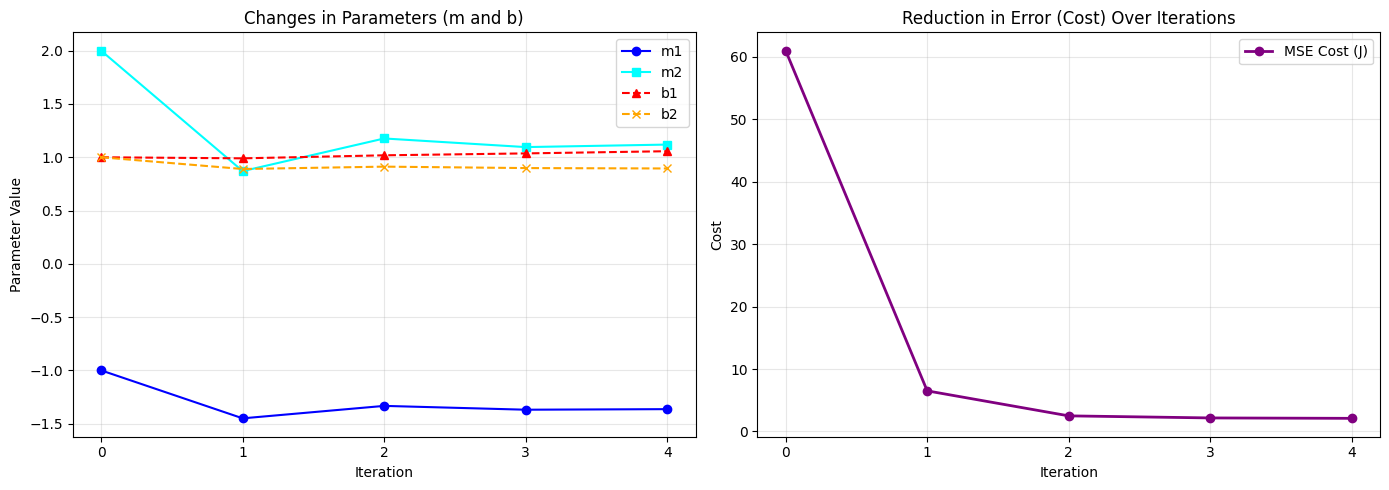

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Parameter trajectories
ax1.plot(m1_history, label='m1', marker='o', linestyle='-', color='blue')
ax1.plot(m2_history, label='m2', marker='s', linestyle='-', color='cyan')
ax1.plot(b1_history, label='b1', marker='^', linestyle='--', color='red')
ax1.plot(b2_history, label='b2', marker='x', linestyle='--', color='orange')
ax1.set_title("Changes in Parameters (m and b)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Parameter Value")
ax1.set_xticks(range(len(m1_history)))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cost curve
ax2.plot(cost_history, label='MSE Cost (J)', marker='o', color='purple', linewidth=2)
ax2.set_title("Reduction in Error (Cost) Over Iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Cost")
ax2.set_xticks(range(len(cost_history)))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()